#Install necessary packages

In [ ]:
pip install transformers scipy

In [ ]:
pip install tf-keras dvclive

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 470.1/470.1 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.2/74.2 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.9/374.9 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 51.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.3/79.3 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 451.2/451.2 kB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.2/214.2 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.

#import Dependencies

In [ ]:
from datasets import load_dataset
import pandas as pd
import torch
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification
from transformers import pipeline
from transformers import DataCollatorWithPadding
from transformers import AutoConfig
from transformers import AutoModel
from scipy.special import softmax
from dvclive.huggingface import DVCLiveCallback
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from transformers import TrainingArguments
from transformers import Trainer
import numpy as np
from sklearn.metrics import classification_report

# Load Dataset

In [ ]:
dataset = load_dataset("cardiffnlp/tweet_eval", "sentiment") #Load the dataset

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

sentiment/train-00000-of-00001.parquet:   0%|          | 0.00/3.78M [00:00<?, ?B/s]

sentiment/test-00000-of-00001.parquet:   0%|          | 0.00/901k [00:00<?, ?B/s]

sentiment/validation-00000-of-00001.parq(…):   0%|          | 0.00/167k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/45615 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/12284 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

#Data Exploration

In [ ]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 45615
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 12284
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [ ]:
train_set = dataset["train"] # Load training set
train_set

Dataset({
    features: ['text', 'label'],
    num_rows: 45615
})

In [ ]:
train_set[0] # First tweet in the dataset

{'text': '"QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin"',
 'label': 2}

# Each numerical label is a sentiment:


- 0 - **Negative**
- 1 - **Neutral**
- 2 - **Positive**

# Download a Pre-trained model (roBERTa)





In [ ]:
# Setup a pytorch device
device = torch.device("cuda" if torch.cuda.is_available()
 else "mps"
                      if torch.backends.mps.is_available()
                       else "cpu" )

# Perform Tokenisation (with padding and truncation)

In [ ]:
task='sentiment'
MODEL = f"cardiffnlp/twitter-roberta-base-{task}"

tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL)
model.save_pretrained(MODEL) # Save pretrained model
model.to(device) # Save model to device

config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

# Define tokenization

In [ ]:
def tokenize_function(batch):
  return tokenizer(batch["text"], truncation=True, padding = True)

tokenized_dataset = dataset.map(tokenize_function,batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

Map:   0%|          | 0/45615 [00:00<?, ? examples/s]

Map:   0%|          | 0/12284 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
# Tested on 2 rows
print(tokenize_function(dataset["train"][:2]))

{'input_ids': [[0, 113, 1864, 565, 787, 12105, 96, 5, 1461, 2479, 9, 5, 262, 212, 1040, 6, 8022, 687, 26110, 179, 5601, 5, 9846, 9, 42210, 4, 849, 21136, 44728, 1208, 31157, 687, 574, 658, 179, 113, 2], [0, 113, 17521, 1259, 1589, 1259, 36, 3865, 33825, 43, 1189, 66, 9, 5, 4451, 296, 6, 11292, 849, 487, 8064, 849, 104, 863, 113, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]], 'attention_mask': [[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]}


# Visualise a subset of text examples along with their corresponding positive, negative, or neutral labels

In [ ]:
dataset.set_format(type="pandas")
df = dataset["train"][:]
df.head() # Turn dataset into pandas dataframe

,text,label
0,"""QT @user In the original draft of the 7th boo...",2
1,"""Ben Smith / Smith (concussion) remains out of...",1
2,Sorry bout the stream last night I crashed out...,1
3,Chase Headley's RBI double in the 8th inning o...,1
4,@user Alciato: Bee will invest 150 million in ...,2


In [ ]:
# Assign labels to numerical labels
def label_converter(row):
  return dataset["train"].features["label"].int2str(row)

In [ ]:
df["label_name"]=df["label"].apply(label_converter) # Apply converter to assign sentiments to the numerical data
df.head() # Load the first few lines of the

,text,label,label_name
0,"""QT @user In the original draft of the 7th boo...",2,positive
1,"""Ben Smith / Smith (concussion) remains out of...",1,neutral
2,Sorry bout the stream last night I crashed out...,1,neutral
3,Chase Headley's RBI double in the 8th inning o...,1,neutral
4,@user Alciato: Bee will invest 150 million in ...,2,positive


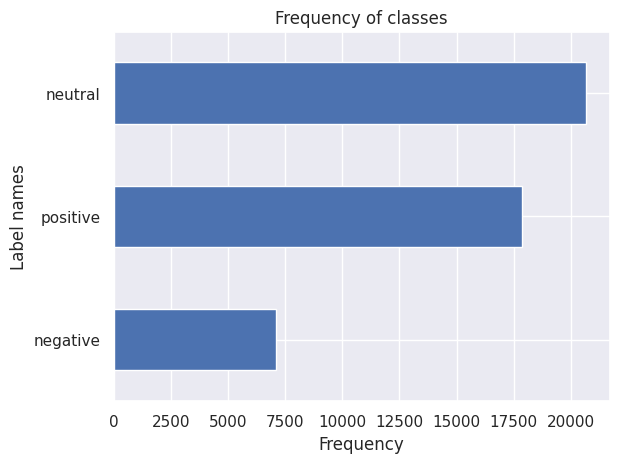

In [ ]:
# Creating a bar graph to demonstrate balance in sentiments
sns.set_theme()
df["label_name"].value_counts(ascending=True).plot.barh()
plt.title("Frequency of classes")
plt.xlabel("Frequency")
plt.ylabel("Label names")
plt.show()

## Graph suggests data is imbalanced.

Where there is a large gap between neutral and negative tweets.

# Formating data

In [ ]:
dataset.reset_format()

# Split the dataset into training, validation, and testing sets.

In [ ]:
train_set = dataset["train"] # Train set
test_set = dataset["test"] # Test set
val_set = dataset["validation"] # Validation set

In [ ]:
df # Load data frame

,text,label,label_name
0,"""QT @user In the original draft of the 7th boo...",2,positive
1,"""Ben Smith / Smith (concussion) remains out of...",1,neutral
2,Sorry bout the stream last night I crashed out...,1,neutral
3,Chase Headley's RBI double in the 8th inning o...,1,neutral
4,@user Alciato: Bee will invest 150 million in ...,2,positive
...,...,...,...
45610,"@user \""""So amazing to have the beautiful Lady...",2,positive
45611,"9 September has arrived, which means Apple's n...",2,positive
45612,Leeds 1-1 Sheff Wed. Giuseppe Bellusci securin...,2,positive
45613,@user no I'm in hilton head till the 8th lol g...,1,neutral


In [ ]:
X = df["text"] # Features
y = df['label'] # Target

In [ ]:
# Split the data into train, test and val - 80/10/10
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.111, random_state=42) # 10/90 = 0.111



In [ ]:
print(X_train.shape, y_train.shape) # Training shape
print(X_val.shape, y_val.shape) # Testing shape
print(X_test.shape, y_test.shape ) # Validation shape

(36496,) (36496,)
(4557,) (4557,)
(4562,) (4562,)


# Fine-tuning

RoBERTa based - model 1

Tokenize model

In [ ]:
MODEL_1 = "roberta-base" # Roberta base model from huggingface
tokenizer_1 = AutoTokenizer.from_pretrained(MODEL_1) # Tokenising roberta model

model_rt = AutoModel.from_pretrained(MODEL_1) # Loads the models pretrained achitecture


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model architecture - RoBERTa

In [ ]:
model_rt # Load model architecture

RobertaModel(
  (embeddings): RobertaEmbeddings(
    (word_embeddings): Embedding(50265, 768, padding_idx=1)
    (token_type_embeddings): Embedding(1, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (position_embeddings): Embedding(514, 768, padding_idx=1)
  )
  (encoder): RobertaEncoder(
    (layer): ModuleList(
      (0-11): 12 x RobertaLayer(
        (attention): RobertaAttention(
          (self): RobertaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): RobertaSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
            (dropou

Model configurations

In [ ]:
model_rt.config # Load model configuration architecture

RobertaConfig {
  "add_cross_attention": false,
  "architectures": [
    "RobertaForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": 0,
  "classifier_dropout": null,
  "dtype": "float32",
  "eos_token_id": 2,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "is_decoder": false,
  "layer_norm_eps": 1e-05,
  "max_position_embeddings": 514,
  "model_type": "roberta",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 1,
  "tie_word_embeddings": true,
  "transformers_version": "5.0.0",
  "type_vocab_size": 1,
  "use_cache": true,
  "vocab_size": 50265
}

In [ ]:
model_rt.config.id2label # Loads the id 2 label configurations

{0: 'LABEL_0', 1: 'LABEL_1'}

In [ ]:
model_rt.config.label2id # Loads the label 2 id configurations

{'LABEL_0': 0, 'LABEL_1': 1}

In [ ]:
id2label = {0: 'Negative', 1: 'Neutral', 2: 'Positive'} # Assign sentiments to id 2 label
label2id = {'Negative': 0, 'Neutral': 1, 'Positive': 2} # Assign sentiments to label 2 id

In [ ]:
# Now we fine-tune transformers
num_labels = len(label2id)
device = torch.device("cuda" if torch.cuda.is_available() else "mps"if torch.backends.mps.is_available()else "cpu" )

In [ ]:
# Define tokenisation
def tokenize_function(batch):
  return tokenizer_1(batch["text"], truncation=True, padding = True)

tokenized_dataset = dataset.map(tokenize_function,batched=True)

data_collator_1 = DataCollatorWithPadding(tokenizer=tokenizer_1)

Map:   0%|          | 0/45615 [00:00<?, ? examples/s]

Map:   0%|          | 0/12284 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
config_1 = AutoConfig.from_pretrained(MODEL_1, label2id=label2id, id2label=id2label) # convert prediction to readable label format
model_1 = AutoModelForSequenceClassification.from_pretrained(MODEL_1, config=config_1).to(device) # Save to device
# Note: config only worked with MODEL and not model becuase model isnt a string

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
model_1 # Load New model architecture

RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

In [ ]:
model_1.config # Load New configuration architecture

RobertaConfig {
  "add_cross_attention": false,
  "architectures": [
    "RobertaForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": 0,
  "classifier_dropout": null,
  "dtype": "float32",
  "eos_token_id": 2,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "id2label": {
    "0": "Negative",
    "1": "Neutral",
    "2": "Positive"
  },
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "is_decoder": false,
  "label2id": {
    "Negative": 0,
    "Neutral": 1,
    "Positive": 2
  },
  "layer_norm_eps": 1e-05,
  "max_position_embeddings": 514,
  "model_type": "roberta",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 1,
  "tie_word_embeddings": true,
  "transformers_version": "5.0.0",
  "type_vocab_size": 1,
  "use_cache": true,
  "vocab_size": 50265
}

## Training arguments from tansformers

In [ ]:
batch_size = 16 # Batch size
training_dir = "roberta_base_train_dir" # Training directory
training_args = TrainingArguments(
    output_dir = training_dir,
    num_train_epochs=2, # Training on 2 epochs
    learning_rate = 1.25e-5, # Learning rate
    per_device_train_batch_size = 10, # Batch size for training
    per_device_eval_batch_size = 12, # Batch size for evaluation
    warmup_steps = 1, # Warm-up steps
    weight_decay = 0.01, # Weight decay
    logging_steps=10, # Logging steps
    eval_strategy="epoch", # Evaluation strategy
    disable_tqdm= None) # Manages progress bar display



# Fine tuning trainer

In [ ]:
trainer = Trainer(
    model=model_1,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    processing_class=tokenizer_1,
    data_collator = data_collator_1) # Train pretrained model

In [ ]:
trainer.train() # Load trained pretrained model

Epoch,Training Loss,Validation Loss
1,0.838198,0.886479
2,0.766800,0.855441


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=9124, training_loss=0.878056092306168, metrics={'train_runtime': 2867.0641, 'train_samples_per_second': 31.82, 'train_steps_per_second': 3.182, 'total_flos': 4351423147298640.0, 'train_loss': 0.878056092306168, 'epoch': 2.0})

BERT

In [ ]:
# Setup a pytorch device
device = torch.device("cuda" if torch.cuda.is_available()
 else "mps"
                      if torch.backends.mps.is_available()
                       else "cpu" )

In [ ]:
MODEL_2="bert-base-uncased" # Load pretrained model from hugging face

tokenizer_2 = AutoTokenizer.from_pretrained(MODEL_2) # Tokenize pretrained model
model_2 = AutoModel.from_pretrained(MODEL_2) # Loads model achitecture by name

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
model_2

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

In [ ]:
model_2.config # Load configuration architecture

BertConfig {
  "add_cross_attention": false,
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": null,
  "classifier_dropout": null,
  "dtype": "float32",
  "eos_token_id": null,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "is_decoder": false,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "tie_word_embeddings": true,
  "transformers_version": "5.0.0",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 30522
}

In [ ]:
# Define tokenized function
def tokenize_function(batch):
  return tokenizer_2(batch["text"], truncation=True, padding = True)

tokenized_dataset = dataset.map(tokenize_function,batched=True) # Tokenize dataset

data_collator_2 = DataCollatorWithPadding(tokenizer=tokenizer_2) # Add data collator

Map:   0%|          | 0/45615 [00:00<?, ? examples/s]

Map:   0%|          | 0/12284 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
config = AutoConfig.from_pretrained(MODEL_2, label2id=label2id, id2label=id2label) # Saving our model will convert predict to readable label format
model_2 = AutoModelForSequenceClassification.from_pretrained(MODEL_2, config=config).to(device) # Save to device

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
model_2 # New model architecture

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [ ]:
model_2.config # New model configuration architecture

BertConfig {
  "add_cross_attention": false,
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": null,
  "classifier_dropout": null,
  "dtype": "float32",
  "eos_token_id": null,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "id2label": {
    "0": "Negative",
    "1": "Neutral",
    "2": "Positive"
  },
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "is_decoder": false,
  "label2id": {
    "Negative": 0,
    "Neutral": 1,
    "Positive": 2
  },
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "tie_word_embeddings": true,
  "transformers_version": "5.0.0",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 30522
}

In [ ]:
# Training arguments from tansformers
batch_size = 64
training_dir = "bert_base_uncased_train_dir"
training_args = TrainingArguments(
    output_dir = training_dir,
    num_train_epochs=2, # Training on 2 epochs
    learning_rate = 1e-05, # Learning rate
    per_device_train_batch_size = batch_size,  # Batch size for training
    per_device_eval_batch_size = batch_size, # Batch size for evaluation
    warmup_steps = 500, # Warm-up steps
    weight_decay = 0.01, # Weight decay
    logging_steps=10, # Logging steps
    eval_strategy="epoch", # Evaluation strategy
    disable_tqdm= None)  # Manages progress bar display

In [ ]:
# Train pretrained model
trainer_2 = Trainer(
    model=model_2,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    processing_class=tokenizer_2,
    data_collator = data_collator_2)

In [ ]:
# Load trained model
trainer_2.train()

Epoch,Training Loss,Validation Loss
1,0.648883,0.636429
2,0.608966,0.619338


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1426, training_loss=0.7121900783180355, metrics={'train_runtime': 1773.3321, 'train_samples_per_second': 51.446, 'train_steps_per_second': 0.804, 'total_flos': 5258136651672240.0, 'train_loss': 0.7121900783180355, 'epoch': 2.0})


Evaluation

In [ ]:
trainer.evaluate() # Evaluate RoBERTa base model

{'eval_loss': 0.8554410338401794,
 'eval_runtime': 8.8512,
 'eval_samples_per_second': 225.959,
 'eval_steps_per_second': 18.868,
 'epoch': 2.0}

In [ ]:
trainer_2.evaluate() # Evaluate BERT base model

{'eval_loss': 0.6193379759788513,
 'eval_runtime': 7.6048,
 'eval_samples_per_second': 262.99,
 'eval_steps_per_second': 4.208,
 'epoch': 2.0}

Model predicting on the test set of the tokenized dataset

In [ ]:
# performing prediction on test set - RoBERTa

pred_1 = trainer.predict(tokenized_dataset['test'])
pred_1.metrics

{'test_loss': 1.0386805534362793,
 'test_runtime': 48.1596,
 'test_samples_per_second': 255.069,
 'test_steps_per_second': 21.263}

In [ ]:
# performing prediction on test set - BERT
pred_2 = trainer_2.predict(tokenized_dataset['test'])
pred_2.metrics

{'test_loss': 0.668415367603302,
 'test_runtime': 42.5143,
 'test_samples_per_second': 288.938,
 'test_steps_per_second': 4.516}

In [ ]:
# load predictions
pred_1.predictions

array([[ 0.6597014 ,  1.1132114 , -1.4770715 ],
       [-0.6931553 ,  0.91417265, -0.07926998],
       [-0.41891152,  0.98569775, -0.36854267],
       ...,
       [-0.5919965 ,  1.609891  , -0.71209323],
       [-0.6411092 ,  0.50692046,  0.20120433],
       [-0.7888244 ,  1.2472285 , -0.2286711 ]], dtype=float32)

In [ ]:
# y pred and y true - RoBERTa
y_pred_1= np.argmax(pred_1.predictions, axis=1)
y_true = tokenized_dataset['test'][:]['label']

In [ ]:
# Model classification report - RoBERTa
print(classification_report(y_true, y_pred_1))

              precision    recall  f1-score   support

           0       0.60      0.20      0.30      3972
           1       0.55      0.76      0.64      5937
           2       0.47      0.56      0.51      2375

    accuracy                           0.54     12284
   macro avg       0.54      0.51      0.48     12284
weighted avg       0.55      0.54      0.50     12284



In [ ]:
# y pred and y true -BERT
y_pred_2= np.argmax(pred_2.predictions, axis=1)
y_true = tokenized_dataset['test'][:]['label']

In [ ]:
# Model classification report - BERT
print(classification_report(y_true, y_pred_2))

              precision    recall  f1-score   support

           0       0.69      0.75      0.72      3972
           1       0.73      0.66      0.69      5937
           2       0.65      0.72      0.68      2375

    accuracy                           0.70     12284
   macro avg       0.69      0.71      0.70     12284
weighted avg       0.70      0.70      0.70     12284



In [ ]:
pred_2.predictions

array([[ 1.8203754 ,  0.48402095, -1.6046759 ],
       [-1.217557  ,  0.73916465,  1.1251196 ],
       [ 0.856284  ,  0.69351155, -0.96805084],
       ...,
       [-0.35219014,  1.3104243 , -1.5793371 ],
       [ 2.3247795 , -0.19109495, -0.93346876],
       [-2.1086285 ,  0.52651316,  2.080476  ]], dtype=float32)

References :

Abbas J (2026). Reg_cardekho_80_10_10 [online] https://canvas.kingston.ac.uk/courses/34089/pages/topic-2-neural-networks-and-deep-learning [Accessed 27 April 2026]

cardiffnlp (n.d.). cardiffnlp/twitter-roberta-base-sentiment. Hugging Face[online] Available at: https://huggingface.co/cardiffnlp/twitter-roberta-base-sentiment. [Accessed 25 Apr 2026]

Clark, C. and Chen, N. (2025). Large Language Model-Based Malware Detection for the Windows Operating System. Journal of Cybersecurity, Digital Forensics and Jurisprudence, 1, pp.3-4. doi:https://doi.org/10.65879/3070-5789.2025.01.09. [Accessed 3 May 2026]

DVCorg (2023). Tweet Sentiment Analyzer with DVC and Huggingface. [online] YouTube. Available at: https://www.youtube.com/watch?v=TNW5KyFAy8U [Accessed 25 April 2026].

Evren Ozkip (2023). SENTIMENT ANALYSIS with HUGGING FACE TRANSFORMERS. [online] YouTube. Available at: https://www.youtube.com/watch?v=OFed5PdDAJI [Accessed 25 April 2026].

Huggingface. (2025). Available at: https://huggingface.co/docs/transformers/v5.6.2/en/main_classes/trainer#transformers.TrainingArguments [Accessed 27 May
2026].

Huggingface (n.d.). Fine-tune a pretrained model. [online] Available at: https://huggingface.co/docs/transformers/en/training. [Accessed 27 May 2026].

KGP Talkie (2024). Fine-Tune BERT for Multi-Class Sentiment Classification with Twitter Data | Python & Streamlit. [online] YouTube. Available at: https://www.youtube.com/watch?v=NjndMvmIiec [Accessed 25 April 2026].

Moesta, P. (2024). Fine-Tuning a Pre-Trained RoBERTa Model to Improve Performance on Domain Specific Sentiment Analysis Task. [online] Medium. Available at: https://medium.com/@parkermo_86729/fine-tuning-a-pre-trained-roberta-model-to-improve-performance-on-domain-specific-sentiment-e6fcd89a1546. [Accessed 27 April 2026].

Renotte, N. (2021). Sentiment Analysis with BERT Neural Network and Python. YouTube. Available at: https://www.youtube.com/watch?v=szczpgOEdXs. [Accessed 27 April 2026].

Running (2021). Running with no end when usin the pipeline Trainer for the transformers. [online] PyTorch Forums. Available at: https://discuss.pytorch.org/t/running-with-no-end-when-usin-the-pipeline-trainer-for-the-transformers/132028/4 [Accessed 5 May 2026].

Tan, V. (2021). Fine-tuning pretrained NLP models with Huggingface’s Trainer. [online] Medium. Available at: https://medium.com/data-science/fine-tuning-pretrained-nlp-models-with-huggingfaces-trainer-6326a4456e7b [Accessed 5 May 2026].

W3schools (n.d.). Matplotlib Labels and Title. [online] Available at: https://www.w3schools.com/python/matplotlib_labels.asp. [Accessed 29 April 2026].

# APPENDIX II
This submission is my own independent work and all sources used in the submission are referenced. Generative AI was USED for this submission, as outlined by the relevant references. I provide a record of the main prompts given to the generative AI tool, and responses received below.

***ChatGPT***

Purpose:
To address overfitting for the RoBERTA base trainer
Prompt:
Is 15% overfitting bad for a Roberta base fine tune model?
This is the pipeline:

TrainingArguments(
    output_dir = training_dir,

    num_train_epochs=2,

    learning_rate = 5e-05,

    per_device_train_batch_size = 8,

    per_device_eval_batch_size = 12,
    
    warmup_steps = 500,
    
    weight_decay = 0.01,
    
    logging_steps=10,
    
    eval_strategy="epoch",
    
    disable_tqdm= None)


Response:

A 15% overfitting gap (for example, training accuracy/F1 is ~15 points higher than validation/test) on a RoBERTa-base fine-tune is usually a sign that generalization could be improved, though whether it’s “bad” depends on the task, dataset size, and absolute performance.

Most probable culprit for the 15% overfitting:

learning_rate = 5e-5 + warmup_steps = 500

Reducing LR and using proportional warmup should produce more balanced train/validation metrics. Hugging Face documentation commonly uses ~2e-5 and a few epochs as a strong starting point for transformer fine-tuning.


Gemini

purpose: To help explain the error.

Prompt: Explain Error

Response:
config_1 = AutoConfig.from_pretrained(**MODEL_1**, label2id=label2id, id2label=id2label) # Saving our model will convert prediction to readable label format
model_1 = AutoModelForSequenceClassification.from_pretrained(**MODEL_1**, config=config_1).to(device) # Save to device # Note: config only worked with MODEL and not model becuase model isnt a string -> changed to model_rt to MODEL_1